In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('tips_DV.csv')

In [3]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [4]:
df.rename(columns = {'size':'peoples'}, inplace = True)

In [5]:
df

,total_bill,tip,sex,smoker,day,time,peoples
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [7]:
df.isna().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
peoples       0
dtype: int64

In [8]:
col_var = df[['peoples','sex', 'smoker', 'day', 'time']]

for i in col_var:
    print(i, df[i].unique())

peoples [2 3 4 1 6 5]
sex ['Female' 'Male']
smoker ['No' 'Yes']
day ['Sun' 'Sat' 'Thur' 'Fri']
time ['Dinner' 'Lunch']


In [9]:
df.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'peoples'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   peoples     244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


## Plots

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# Heatmap

Text(0.5, 1.0, 'Correlation Heatmap')

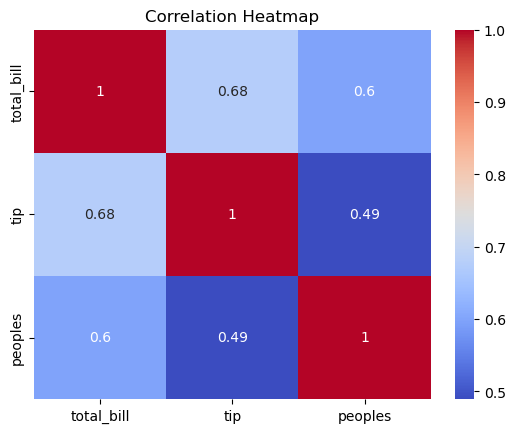

In [13]:
# sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
sns.heatmap(df[['total_bill','tip','peoples']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")

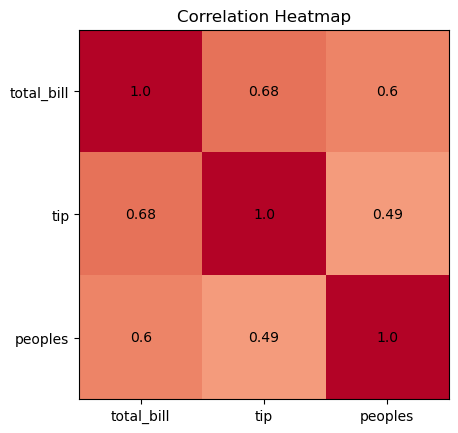

In [14]:
# HEATMAP in matplotlib=> 
plt.imshow(df.corr(numeric_only=True),cmap='coolwarm',vmin=-1,vmax=1,aspect='equal',interpolation='nearest')
corr = df.corr(numeric_only=True)
plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
for i in range(len(corr)):
    for j in range(len(corr)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center', color='black')

# Pairplot

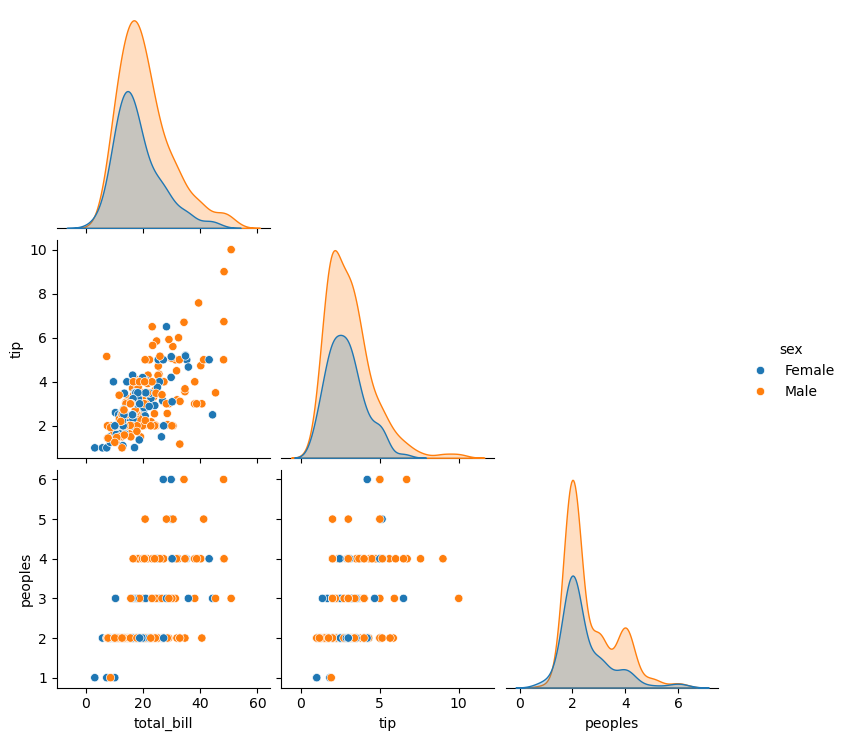

In [18]:
# Pairplot not directly available in matplotlib it is available in seaborn
#sns.pairplot(df,hue="sex",diag_kind="hist",corner=False)
sns.pairplot(df,hue="sex",diag_kind="kde",corner=True)

## Line Plots

<Axes: xlabel='total_bill', ylabel='tip'>

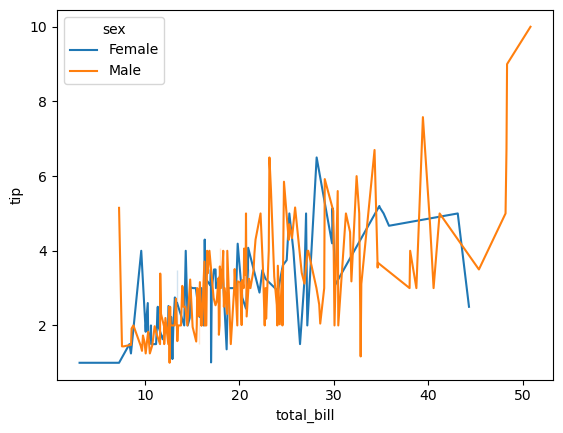

In [57]:
sns.lineplot(df,x='total_bill',y='tip',hue='sex')
# Tip increases as Totl_bill increases

<Axes: xlabel='peoples', ylabel='tip'>

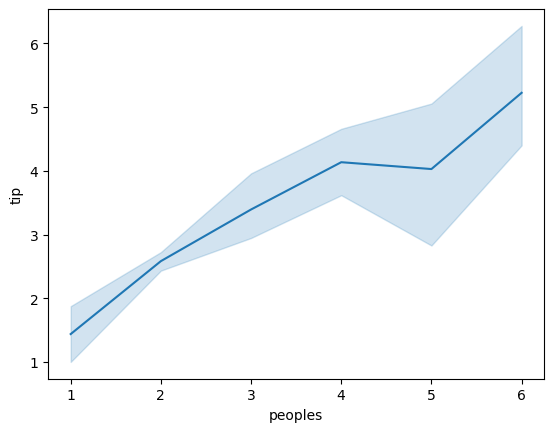

In [19]:
sns.lineplot(df,x='peoples',y='tip')
#sns.lineplot(df,x='peoples',y='tip',errorbar=None) # If You Don’t Want Shaded Area
# As number of people increases, tip generally increases.
# There is a slight dip at 5 people.
# For 6 people, tip increases again.
# The shaded area is wider at higher group sizes → meaning more variability in tip amounts.


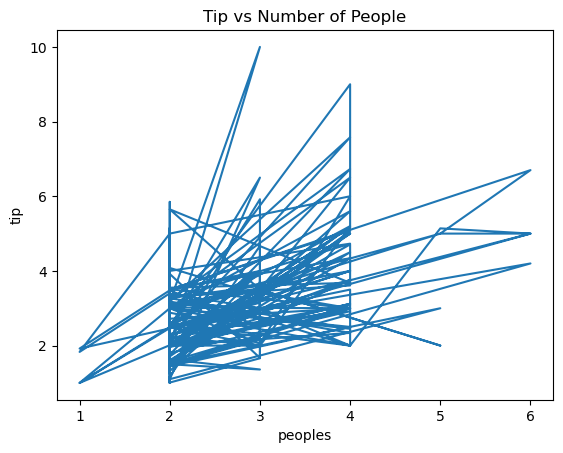

In [20]:
import matplotlib.pyplot as plt

plt.plot(df['peoples'], df['tip'])
plt.xlabel("peoples")
plt.ylabel("tip")
plt.title("Tip vs Number of People")
plt.show()

<Axes: xlabel='peoples', ylabel='tip'>

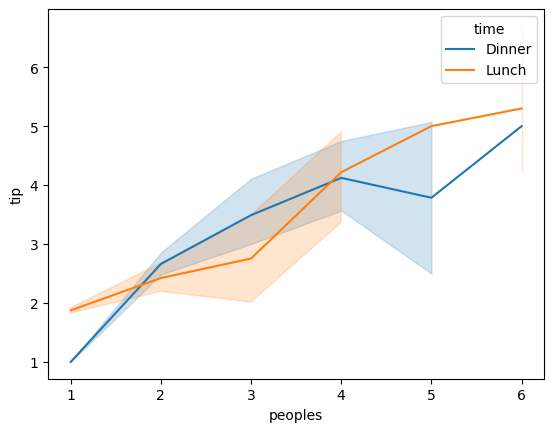

In [82]:
sns.lineplot(df,x='peoples',y='tip',hue='time')
# higher tip at lauch time as compared to Dinner

## Box Plots

<Axes: xlabel='day', ylabel='total_bill'>

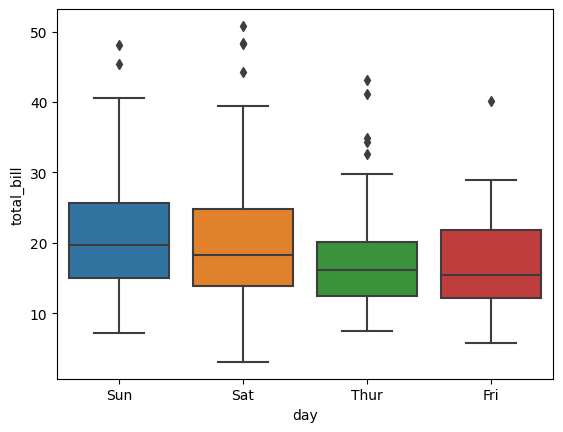

In [14]:
sns.boxplot(df,x='day',y='total_bill')

<Axes: xlabel='peoples', ylabel='total_bill'>

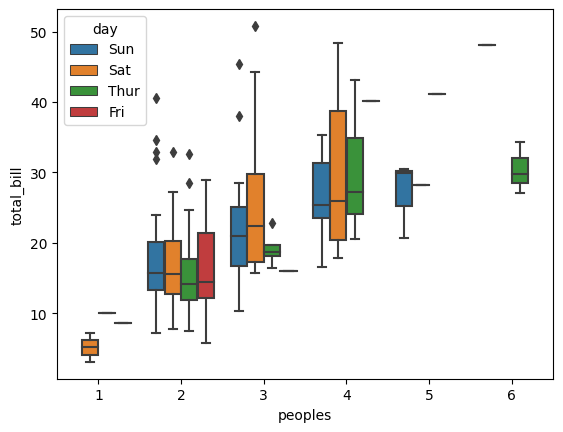

In [15]:
sns.boxplot(df,x='peoples',y='total_bill',hue='day')

<Axes: xlabel='day', ylabel='total_bill'>

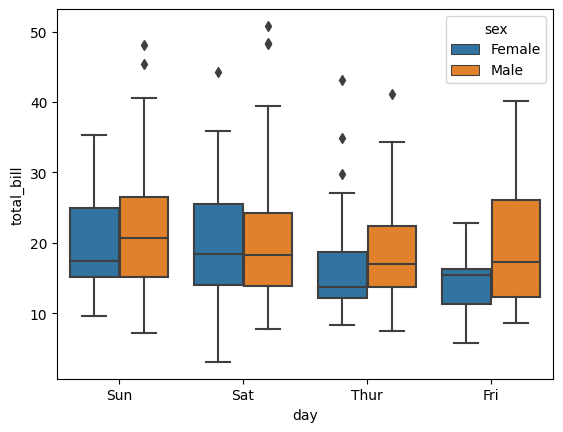

In [16]:
sns.boxplot(df,x='day',y='total_bill',hue='sex')

## Histogram

<Axes: xlabel='total_bill', ylabel='Count'>

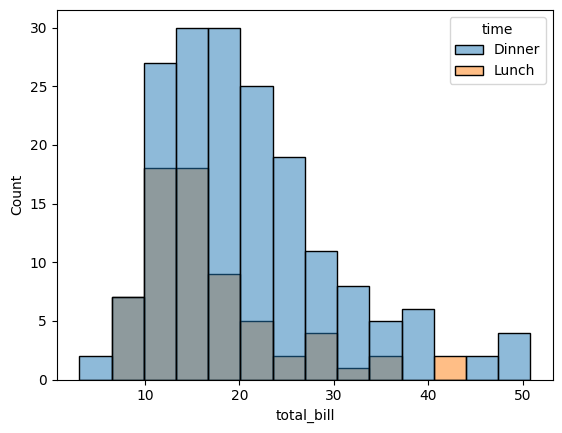

In [17]:
sns.histplot(df,x='total_bill',hue='time')

<Axes: xlabel='tip', ylabel='Count'>

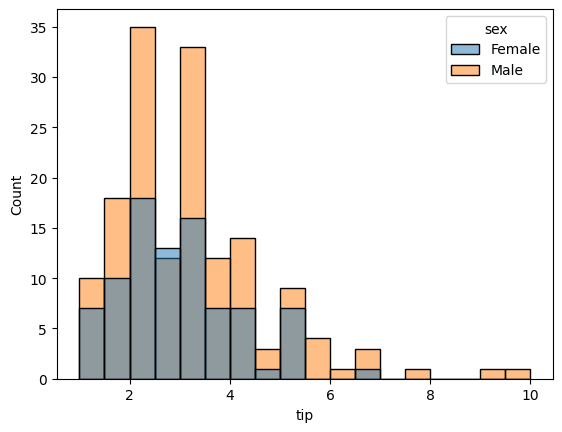

In [18]:
sns.histplot(df,x='tip',hue='sex')

<Axes: xlabel='tip', ylabel='Count'>

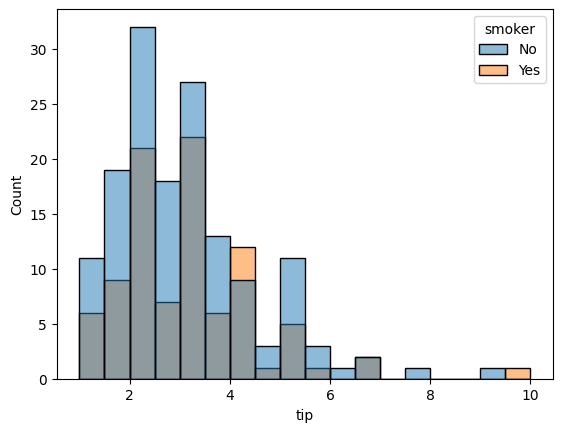

In [19]:
sns.histplot(df,x='tip',hue='smoker')

## Scatter Plots

<Axes: xlabel='total_bill', ylabel='tip'>

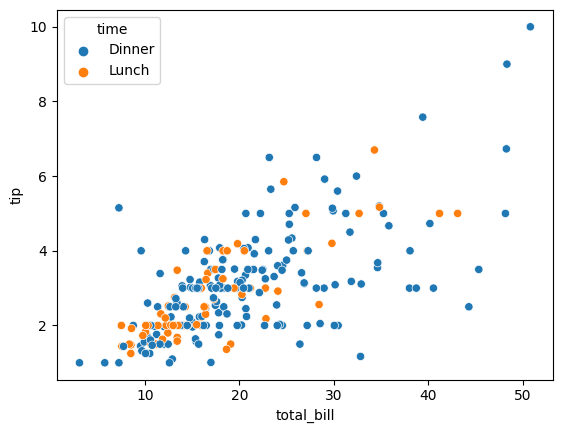

In [20]:
sns.scatterplot(df,x='total_bill',y='tip',hue='time')

<Axes: xlabel='total_bill', ylabel='tip'>

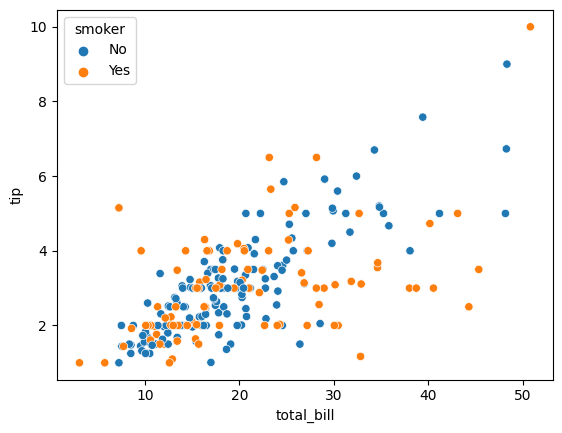

In [21]:
sns.scatterplot(df,x='total_bill',y='tip',hue='smoker')

## Violen

<Axes: xlabel='day', ylabel='tip'>

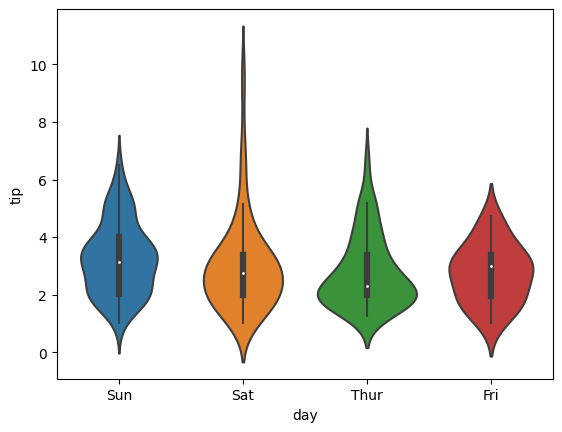

In [22]:

sns.violinplot(df,x ='day', y ='tip')

<Axes: xlabel='time', ylabel='tip'>

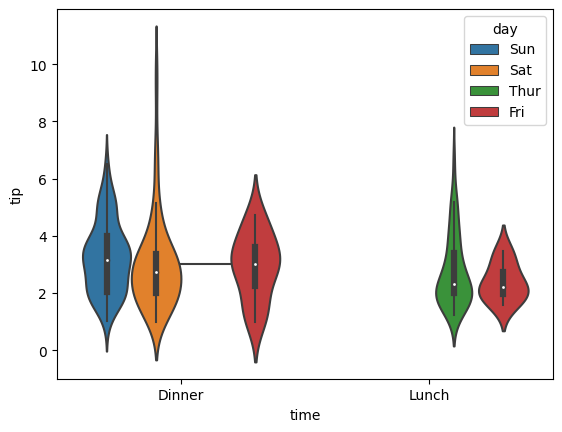

In [23]:
sns.violinplot(df,x ='time', y ='tip',hue='day')

<Axes: xlabel='peoples', ylabel='total_bill'>

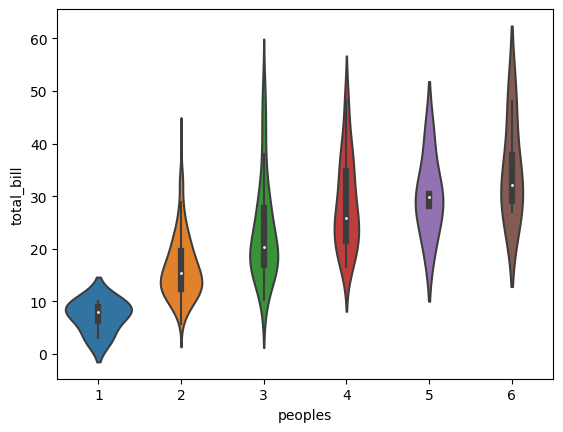

In [24]:
sns.violinplot(df,x ='peoples', y ='total_bill')